In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/var/folders/nd/59qsm7jn2xg352n7b_q91tgh0000gn/T/ipykernel_55460/974463372.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


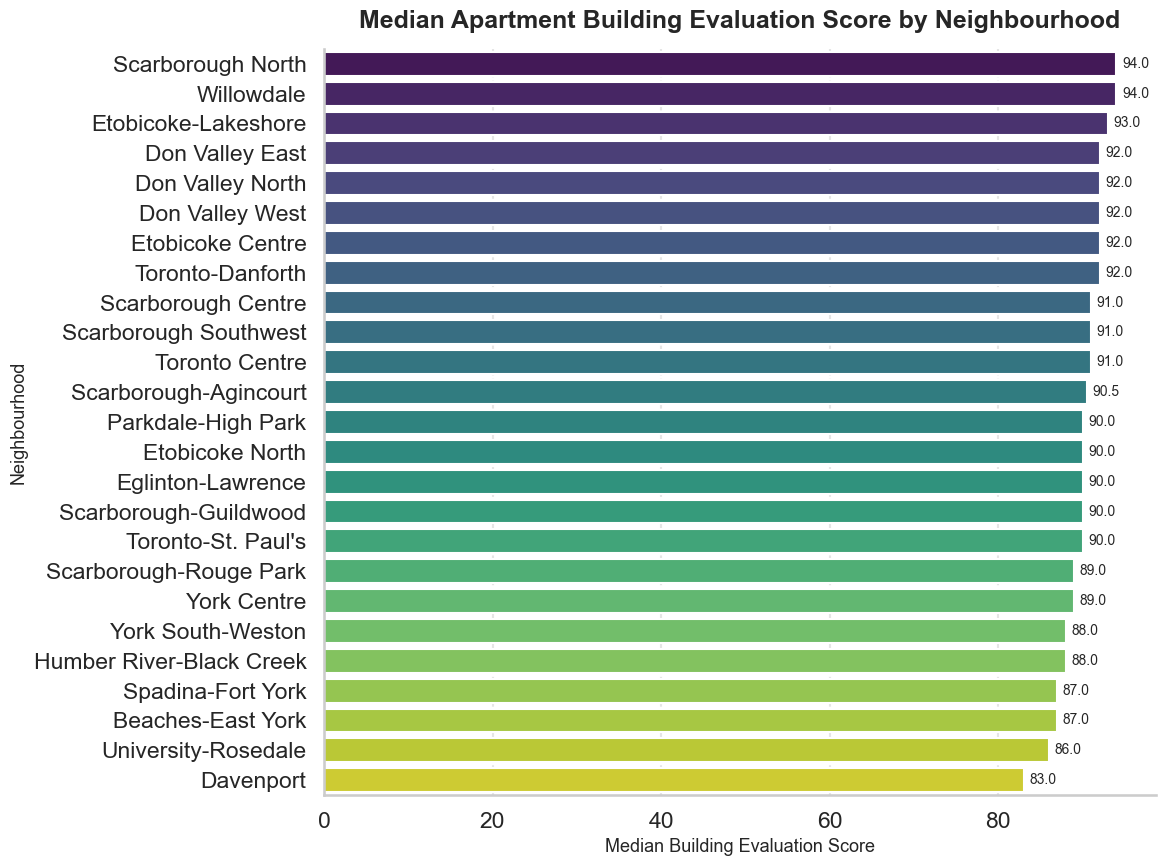

In [ ]:
file_path = Path("/Users/matthewjabile/Downloads/Apartment Building Evaluations 2023 - current.csv")

# Load the dataset
df = pd.read_csv(file_path)

# Select relevant columns and clean data
df = df[['WARDNAME', 'CURRENT BUILDING EVAL SCORE']].copy()

df['CURRENT BUILDING EVAL SCORE'] = pd.to_numeric(
    df['CURRENT BUILDING EVAL SCORE'],
    errors='coerce'
)

# Remove rows with missing or non-numeric evaluation scores
df = df.dropna()

# Calculate median scores by neighbourhood
median_scores = (
    df.groupby('WARDNAME', as_index=False)
      ['CURRENT BUILDING EVAL SCORE']
      .median()
      .sort_values(
          by='CURRENT BUILDING EVAL SCORE',
          ascending=False
      )
)

# Set up the visualization style
sns.set_theme(
    style="whitegrid",
    context="talk"
)

# Create a horizontal bar plot of median evaluation scores by neighbourhood
plt.figure(figsize=(12, 9))

# Use a color palette that emphasizes the differences in scores
colors = sns.color_palette(
    "viridis",
    len(median_scores)
)

# Create the bar plot
ax = sns.barplot(
    data=median_scores,
    x='CURRENT BUILDING EVAL SCORE',
    y='WARDNAME',
    palette=colors
)

# Add value labels to each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=4,
        fontsize=10
    )

# Set titles and labels with improved formatting
plt.title(
    "Median Apartment Building Evaluation Score by Neighbourhood",
    fontsize=18,
    weight='bold',
    pad=15
)

# Set x and y labels with improved formatting
plt.xlabel(
    "Median Building Evaluation Score",
    fontsize=13
)

plt.ylabel(
    "Neighbourhood",
    fontsize=13
)

# Improve grid appearance
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

# Remove spines for a cleaner look
sns.despine(left=False, bottom=False)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the visualization with high resolution
plt.savefig(
    "assignment3_vis1_python_building_evaluation_score.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

/var/folders/nd/59qsm7jn2xg352n7b_q91tgh0000gn/T/ipykernel_56269/274685409.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


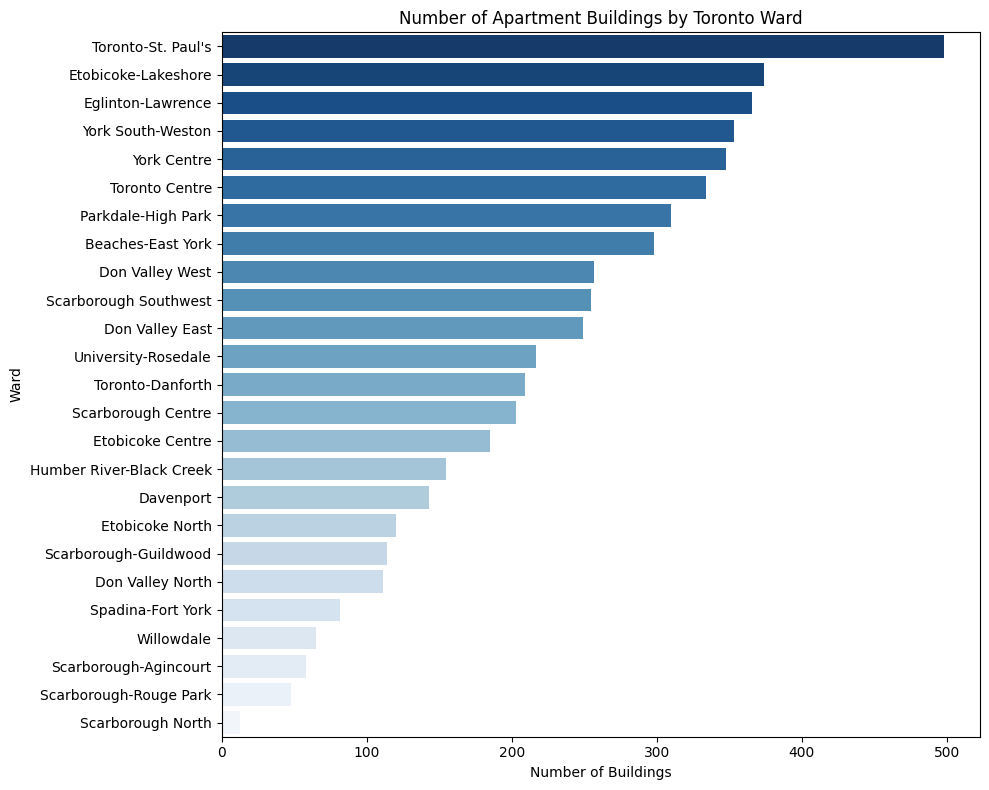

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "/Users/matthewjabile/Downloads/Apartment Building Evaluations 2023 - current.csv"

df = pd.read_csv(file_path)

# Count buildings by ward
ward_counts = (
    df['WARDNAME']
    .dropna()
    .value_counts()
    .reset_index()
)

ward_counts.columns = ['Ward', 'Number of Buildings']

# Set up the visualization style
plt.figure(figsize=(10, 8))

# Create a horizontal bar plot of the number of apartment buildings by ward
sns.barplot(
    data=ward_counts,
    x='Number of Buildings',
    y='Ward',
    palette='Blues_r'
)

# Add value labels to each bar
plt.title("Number of Apartment Buildings by Toronto Ward")
plt.xlabel("Number of Buildings")
plt.ylabel("Ward")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()